/Users/rafael/projects/ml_bootcamp/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
20:12:37 - cmdstanpy - INFO - Chain [1] start processing
20:12:38 - cmdstanpy - INFO - Chain [1] done processing


Prophet requires columns to be strictly named 'ds' (datestamp) and 'y' (numeric).
          ds            y
0 2024-01-01  4813.168530
1 2024-01-02  5596.925395
2 2024-01-03  5724.993727
3 2024-01-04  5384.659090
4 2024-01-05  4956.769617


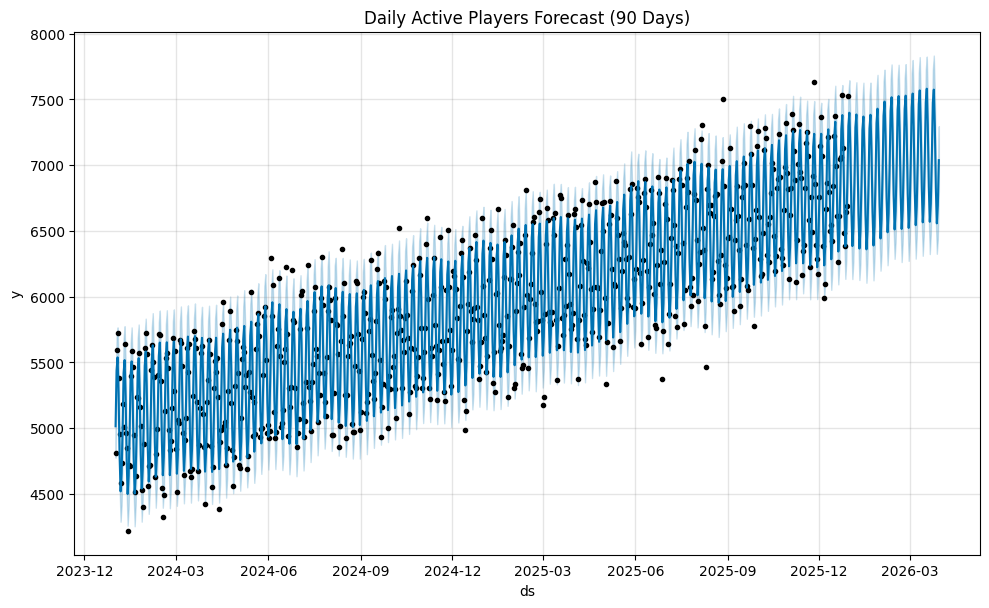

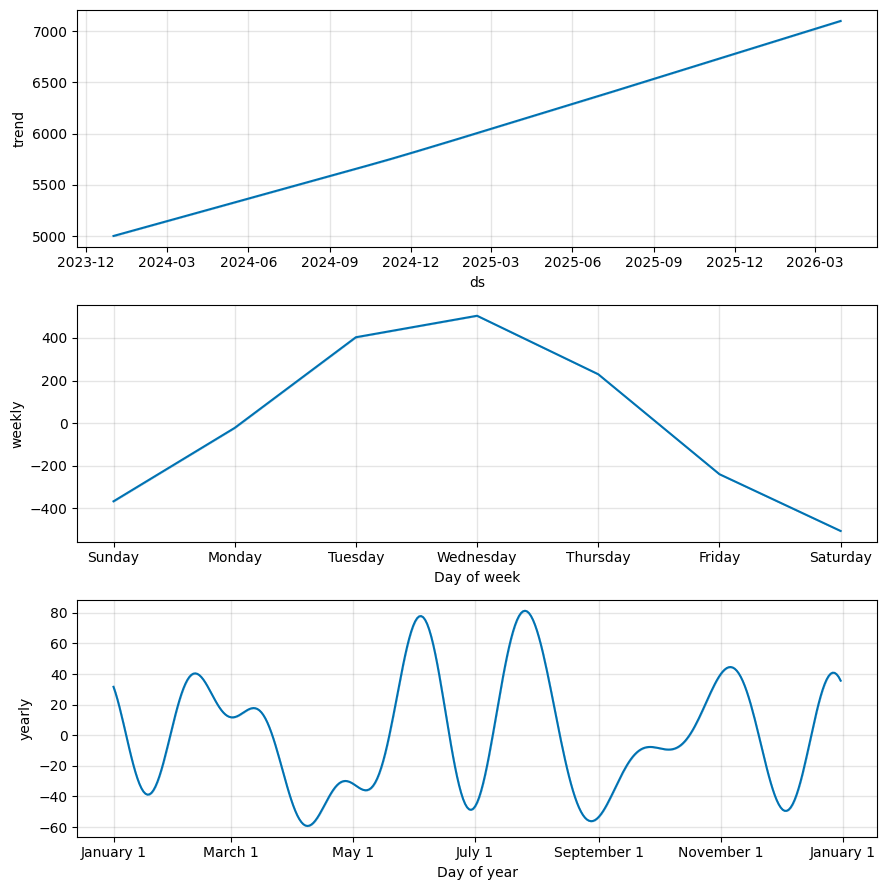

In [1]:
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt

def create_synthetic_data():
    """Generates 2 years of synthetic daily active player data with a slight upward trend."""
    dates = pd.date_range(start='2024-01-01', periods=730)
    # Base baseline + trend + weekly seasonality noise
    y = 5000 + (np.arange(730) * 2.5) + (np.sin(np.arange(730) * (2 * np.pi / 7)) * 500) + np.random.normal(0, 200, 730)
    return pd.DataFrame({'ds': dates, 'y': y})

# 1. Prepare the Data
df = create_synthetic_data()
print("Prophet requires columns to be strictly named 'ds' (datestamp) and 'y' (numeric).")
print(df.head())

# 2. Initialize and Fit the Model
# We set weekly and yearly seasonality to True. Daily is False since we have daily-level data, not hourly.
m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
m.fit(df)

# 3. Create Future DataFrame
# Predict 90 days into the future
future = m.make_future_dataframe(periods=90, freq='D')

# 4. Generate Predictions
# The forecast object contains 'yhat' (prediction), 'yhat_lower', and 'yhat_upper' (uncertainty intervals)
forecast = m.predict(future)

# 5. Visualize the Results
fig1 = m.plot(forecast)
plt.title("Daily Active Players Forecast (90 Days)")
plt.show()

# Plot the individual components (trend, weekly, yearly)
fig2 = m.plot_components(forecast)
plt.show()

20:14:32 - cmdstanpy - INFO - Chain [1] start processing
20:14:32 - cmdstanpy - INFO - Chain [1] done processing


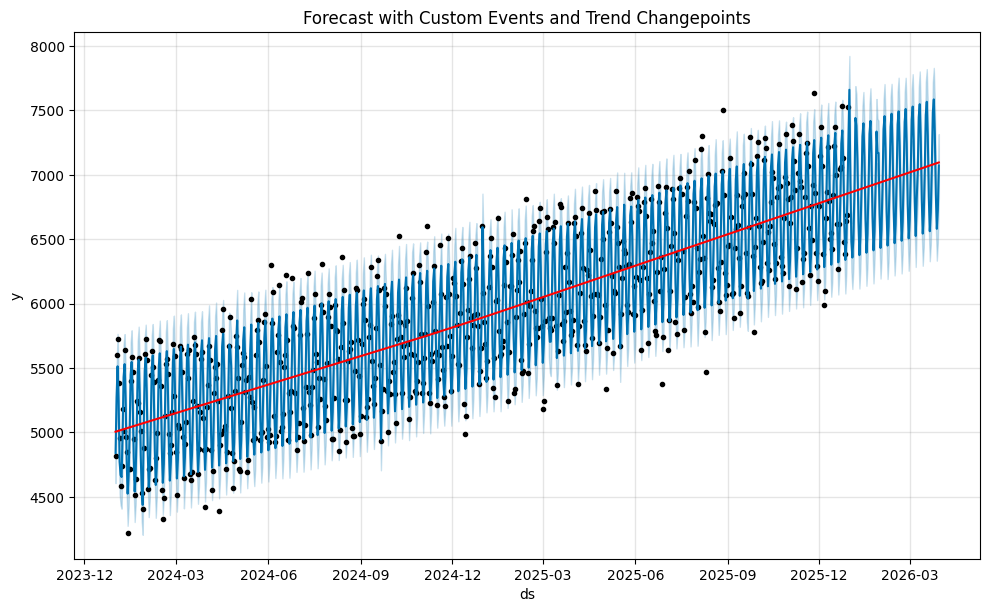

          ds  major_tournament    holidays
0 2024-01-01               0.0 -141.779051
1 2024-01-02               0.0 -141.779051
2 2024-01-03               0.0    0.000000
3 2024-01-04               0.0    0.000000
4 2024-01-05               0.0    0.000000


In [5]:
from prophet.plot import add_changepoints_to_plot

# 1. Define Custom Events (e.g., Major Tournaments or System Outages)
# Prophet accepts a dataframe of events. 'lower_window' and 'upper_window' allow the 
# event to impact the days immediately before and after the exact date.
tournaments = pd.DataFrame({
  'holiday': 'major_tournament',
  'ds': pd.to_datetime(['2024-05-15', '2024-11-20', '2025-05-18']),
  'lower_window': -1, # Effect starts 1 day before
  'upper_window': 2,  # Effect lingers for 2 days after
})

# 2. Initialize Model with Advanced Parameters
# changepoint_prior_scale: Higher value makes the trend more flexible (prone to overfitting)
# holidays_prior_scale: Higher value allows holidays to have a massive impact on the forecast
m_events = Prophet(
    holidays=tournaments,
    changepoint_prior_scale=0.05, 
    holidays_prior_scale=10.0      
)

# You can also easily add built-in country holidays
# Adding Armenia ('AM') or general global holidays helps baseline the model
m_events.add_country_holidays(country_name='AM')

m_events.fit(df)
future_events = m_events.make_future_dataframe(periods=90)
forecast_events = m_events.predict(future_events)

# 3. Visualize Trend Changepoints
# This is a crucial debugging tool to show students WHERE Prophet decided the trend shifted
fig = m_events.plot(forecast_events)
a = add_changepoints_to_plot(fig.gca(), m_events, forecast_events)
plt.title("Forecast with Custom Events and Trend Changepoints")
plt.show()

# Check the impact of the specific holidays
print(forecast_events[['ds', 'major_tournament', 'holidays']].dropna().head())

20:13:16 - cmdstanpy - INFO - Chain [1] start processing
20:13:16 - cmdstanpy - INFO - Chain [1] done processing


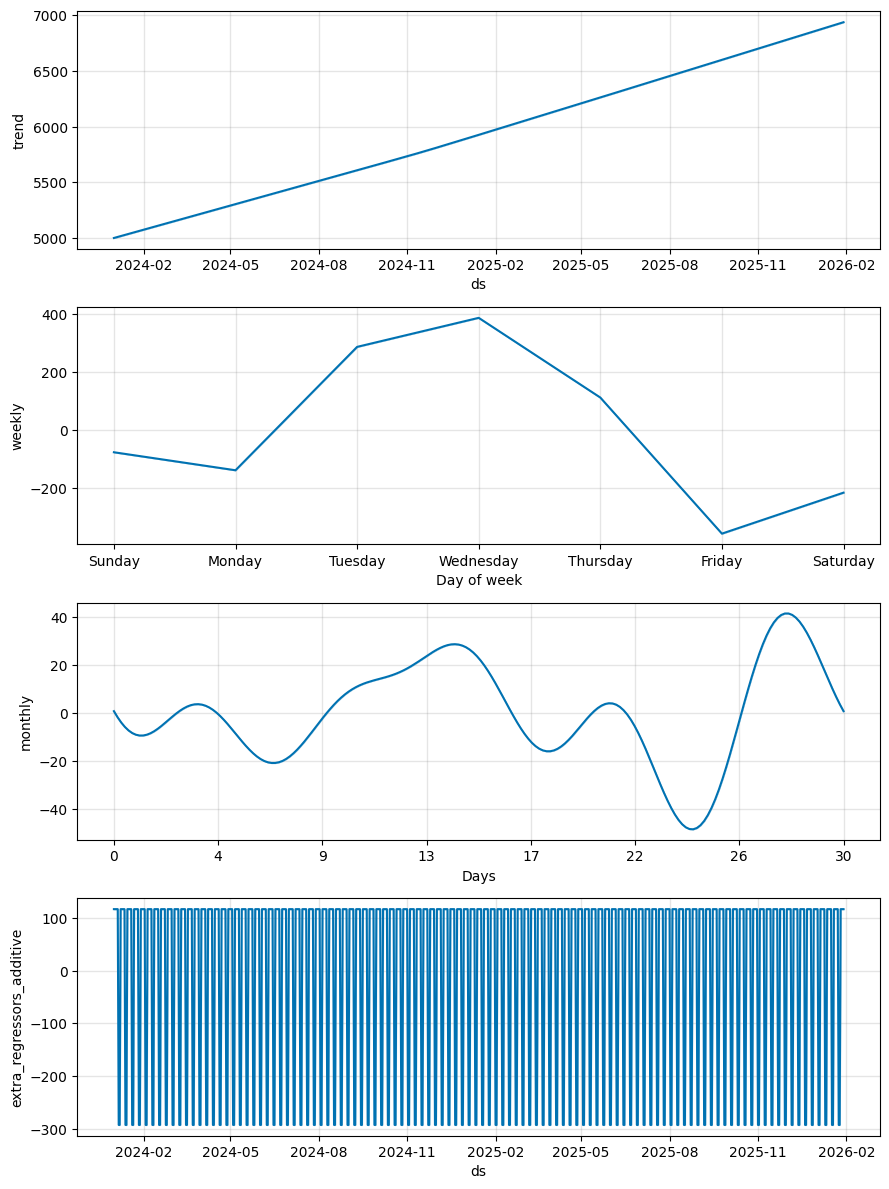

In [3]:
# 1. Engineer the External Regressor Data
# Let's simulate a 'promotional_bonus' metric that spikes on weekends
df['promotional_bonus'] = np.where(df['ds'].dt.dayofweek >= 5, 1000, 200)

# 2. Initialize Model and Add the Regressor
m_reg = Prophet()

# Add a custom monthly seasonality (Prophet defaults to Weekly and Yearly)
# period=30.5 days. fourier_order dictates how complex the seasonal wave can be.
m_reg.add_seasonality(name='monthly', period=30.5, fourier_order=5)

# Add the external regressor
# Note: The regressor MUST be known for future dates to make predictions!
m_reg.add_regressor('promotional_bonus', standardize=True)

m_reg.fit(df)

# 3. Prepare Future Data with the Regressor
future_reg = m_reg.make_future_dataframe(periods=30)

# We must provide the future values for 'promotional_bonus'
# Simulating the continued weekend bonus strategy for the future dataframe
future_reg['promotional_bonus'] = np.where(future_reg['ds'].dt.dayofweek >= 5, 1000, 200)

# 4. Predict and Plot Components
forecast_reg = m_reg.predict(future_reg)
fig = m_reg.plot_components(forecast_reg)
plt.show()